In [2]:
%%capture
%run /Users/norahmiller/Desktop/adcs-project/HW1/HW1_4_5.ipynb
%run /Users/norahmiller/Desktop/adcs-project/HW1/TESS_GeometricModel.ipynb

In [3]:
print("Imported HW1 Sucessfully")

Imported HW1 Sucessfully


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import logm
import time
from scipy.integrate import solve_ivp

## 2 ##

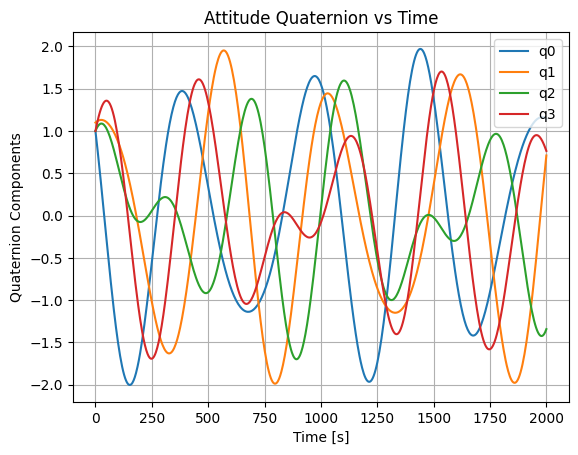

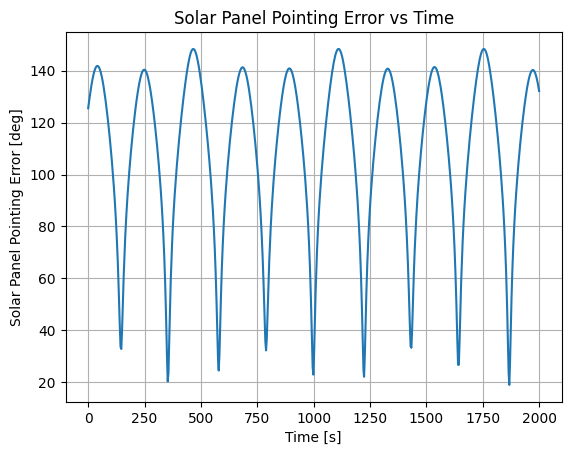

In [8]:

# Gyrostat dynamics function

def gyrostat_dynamics(t, state, J, hr):
    r = state[0:3]
    v = state[3:6]
    q = state[6:10]
    omega = state[10:13]

    # Orbital acceleration
    mu = 398600.4418  # km^3/s^2
    r_norm = np.linalg.norm(r)
    a = -mu * r / r_norm**3

    # Quaternion kinematics
    q0, q1, q2, q3 = q
    Omega = np.array([
        [0, -omega[0], -omega[1], -omega[2]],
        [omega[0], 0, omega[2], -omega[1]],
        [omega[1], -omega[2], 0, omega[0]],
        [omega[2], omega[1], -omega[0], 0]
    ])
    qdot = 0.5 * Omega @ q

    # Angular velocity dynamics
    omega_dot = np.linalg.inv(J) @ ( -np.cross(omega, J @ omega + hr) )

    # Rotor momentum derivative
    hr_dot = np.zeros(3)

    # Concatenate derivative
    dstate = np.concatenate([v, a, qdot, omega_dot, hr_dot])
    return dstate

# Initial conditions TO DO!!

r0 = np.array([7000, 0, 0])  # km
v0 = np.array([0, 7.5, 0])   # km/s

# Perturbed initial attitude quaternion
q0 = np.array([1,1.1,1,1]) # from your HW1.4

omega0 = np.array([0.01, 0.02, 0.015])  # rad/s
hr0 = np.array([0.1, 0.0, 0.0])         # rotor momentum

state0 = np.concatenate([r0, v0, q0, omega0, hr0])


# Inertia matrix

J = np.diag([132.56, 101.64, 89.61])  # from HW1


# Integrate
tspan = (0, 2000)  # seconds (several nutation periods)
sol = solve_ivp(lambda t, y: gyrostat_dynamics(t, y, J, hr0),
                tspan, state0, rtol=1e-9, atol=1e-12)


# Extract results
q_sol = sol.y[6:10,:]  # quaternion
omega_sol = sol.y[10:13,:]

# Solar panel pointing
n_B = np.array([1,0,0])
s_ECI = np.array([1,0,0])

pointing_error = []
for k in range(q_sol.shape[1]):
    qk = q_sol[:,k]
    # Rotation matrix from quaternion
    q0,q1,q2,q3 = qk
    R = np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q1*q3+q0*q2)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q2*q3+q0*q1), 1-2*(q1**2+q2**2)]
    ])
    n_ECI = R @ n_B
    err = np.arccos(np.clip(np.dot(n_ECI, s_ECI)/np.linalg.norm(n_ECI), -1,1))
    pointing_error.append(np.degrees(err))

pointing_error = np.array(pointing_error)

# Plot results
t = sol.t

plt.figure()
plt.plot(t, q_sol.T)
plt.xlabel('Time [s]')
plt.ylabel('Quaternion Components')
plt.title('Attitude Quaternion vs Time')
plt.legend(['q0','q1','q2','q3'])
plt.grid()

plt.figure()
plt.plot(t, pointing_error)
plt.xlabel('Time [s]')
plt.ylabel('Solar Panel Pointing Error [deg]')
plt.title('Solar Panel Pointing Error vs Time')
plt.grid()
plt.show()

## 4. Comparison of Accuracy + Computational Cost for Solving Wahba's Problem ##

In [5]:
# hat operator
def hat(v):
    v = np.asarray(v)
    return np.array([
        [0,     -v[2],  v[1]],
        [v[2],   0,    -v[0]],
        [-v[1],  v[0],  0]
    ])


# un hat
def unhat(S):
    return 0.5 * np.array([
        S[2,1] - S[1,2],
        S[0,2] - S[2,0],
        S[1,0] - S[0,1]
    ])


# constants
H = np.vstack([np.zeros((1,3)), np.eye(3)])

T = np.block([
    [np.ones((1,1)), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])


# quaternion left multiplication matrix
def L(q):
    q = np.asarray(q)
    q0 = q[0]
    qv = q[1:4]

    top = np.hstack([q0, -qv])
    bottom = np.hstack([
        qv.reshape(3,1),
        q0*np.eye(3) + hat(qv)
    ])

    return np.vstack([top, bottom])


# quaternion right multiplication matrix
def R(q):
    q = np.asarray(q)
    q0 = q[0]
    qv = q[1:4]

    top = np.hstack([q0, -qv])
    bottom = np.hstack([
        qv.reshape(3,1),
        q0*np.eye(3) - hat(qv)
    ])

    return np.vstack([top, bottom])


def G(q):
    return L(q) @ H


def Q(q):
    return H.T @ (R(q).T @ L(q)) @ H


# quaternion exponential
def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)

    return np.concatenate([
        [np.cos(theta)],
        phi * np.sinc(theta/np.pi)
    ])

In [6]:
Nmc = 1000
errors_davenport = np.zeros(Nmc)
errors_dyn = np.zeros(Nmc)
errors_newton = np.zeros(Nmc)
errors_triad = np.zeros(Nmc)
time_davenport = 0.0
time_dyn = 0.0
time_newton = 0.0
time_triad = 0.0

for i in range(Nmc):

    #   True attitude  
    qtrue = expq(0.5*np.random.rand(3))
    Qtrue = Q(qtrue)

    #   Random vectors  
    n = 3
    r_B = np.random.rand(3,n)
    for k in range(n):
        r_B[:,k] /= np.linalg.norm(r_B[:,k])
    r_N = Qtrue @ r_B

    #   Add measurement noise  
    for k in range(n):
        r_B[:,k] += 0.1*np.random.randn(3)
        r_B[:,k] /= np.linalg.norm(r_B[:,k])

    w = (1/n)*np.ones(n)

    
    # Davenport q-method
    start = time.time()
    D = np.zeros((4,4))
    for k in range(n):
        D += w[k] * L(H @ r_N[:,k]).T @ R(H @ r_B[:,k])
    eigvals, eigvecs = np.linalg.eigh(D)
    q_dav = eigvecs[:, np.argmax(eigvals)]
    R_err = Q(q_dav).T @ Qtrue
    phi = unhat(logm(R_err))
    errors_davenport[i] = (180/np.pi)*np.linalg.norm(phi)
    time_davenport += time.time() - start
     
    # Dynamic Balance (SVD)
    start = time.time() 
    B = np.zeros((3,3))
    for k in range(n):
        B += w[k] * np.outer(r_B[:,k], r_N[:,k])
    U, _, Vt = np.linalg.svd(B)
    R_dyn = U @ Vt
    if np.linalg.det(R_dyn) < 0:
        U[:,2] *= -1
        R_dyn = U @ Vt
    R_err = R_dyn.T @ Qtrue
    phi = unhat(logm(R_err))
    errors_dyn[i] = (180/np.pi)*np.linalg.norm(phi)
    time_dyn += time.time() - start

     
    # Newton's method
    start = time.time()
    S = B + B.T
    sigma = np.trace(B)
    Z = np.array([
        B[1,2]-B[2,1],
        B[2,0]-B[0,2],
        B[0,1]-B[1,0]
    ])
    K = np.zeros((4,4))
    K[0,0] = sigma
    K[0,1:] = Z
    K[1:,0] = Z
    K[1:,1:] = S - sigma*np.eye(3)
    eigvals, eigvecs = np.linalg.eigh(K)
    q_newton = eigvecs[:, np.argmax(eigvals)]
    R_err = Q(q_newton).T @ Qtrue
    phi = unhat(logm(R_err))
    errors_newton[i] = (180/np.pi)*np.linalg.norm(phi)
    time_newton += time.time() - start

     
    # TRIAD method
    start = time.time()
    # use first two vectors
    t1_B = r_B[:,0]
    t2_B = np.cross(t1_B, r_B[:,1])
    t2_B /= np.linalg.norm(t2_B)
    t3_B = np.cross(t1_B, t2_B)

    t1_N = r_N[:,0]
    t2_N = np.cross(t1_N, r_N[:,1])
    t2_N /= np.linalg.norm(t2_N)
    t3_N = np.cross(t1_N, t2_N)

    R_triad = np.column_stack([t1_B, t2_B, t3_B]) @ np.column_stack([t1_N, t2_N, t3_N]).T
    R_err = R_triad.T @ Qtrue
    phi = unhat(logm(R_err))
    errors_triad[i] = (180/np.pi)*np.linalg.norm(phi)
    time_triad += time.time() - start

Mean Errors
q-method: 10.675651473687045
Dynamic Balance: 110.759523815341
Newton's Method': 10.67565147368706
TRIAD: 110.49553258468406

Std Dev
q-method: 9.188942122983807
Dynamic Balance: 33.712252748072075
Newton's Method: 9.188942122983848
TRIAD: 34.479176849440535

Average Time per Trial (ms)
q-method: 1.1670207977294922
Dynamic Balance: 1.1919291019439697
Newton's Method: 1.058286428451538
TRIAD: 1.2304155826568604


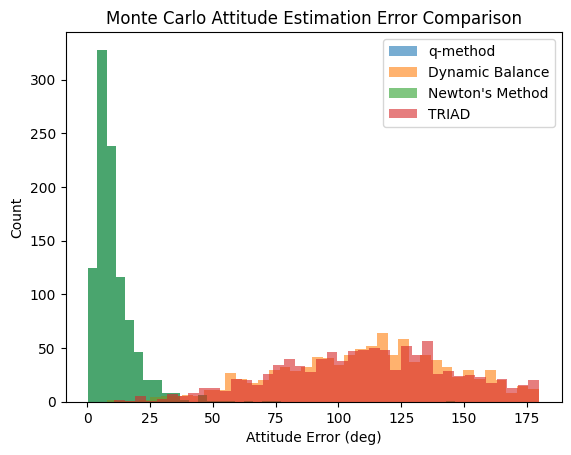

In [7]:
# Results
 
print("Mean Errors")
print("q-method:", np.mean(errors_davenport))
print("Dynamic Balance:", np.mean(errors_dyn))
print("Newton's Method':", np.mean(errors_newton))
print("TRIAD:", np.mean(errors_triad))

print("\nStd Dev")
print("q-method:", np.std(errors_davenport))
print("Dynamic Balance:", np.std(errors_dyn))
print("Newton's Method:", np.std(errors_newton))
print("TRIAD:", np.std(errors_triad))

print("\nAverage Time per Trial (ms)")
print("q-method:", 1000*time_davenport/Nmc)
print("Dynamic Balance:", 1000*time_dyn/Nmc)
print("Newton's Method:", 1000*time_newton/Nmc)
print("TRIAD:", 1000*time_triad/Nmc)
 
# Histogram
plt.hist(errors_davenport, bins=40, alpha=0.6, label="q-method")
plt.hist(errors_dyn, bins=40, alpha=0.6, label="Dynamic Balance")
plt.hist(errors_newton, bins=40, alpha=0.6, label="Newton's Method")
plt.hist(errors_triad, bins=40, alpha=0.6, label="TRIAD")

plt.xlabel("Attitude Error (deg)")
plt.ylabel("Count")
plt.legend()
plt.title("Monte Carlo Attitude Estimation Error Comparison")
plt.show()